# Grizli Comparison: First-Order Star Dispersion

This notebook generates a dispersed grism image of 5 test stars through the Roman WFI
first spectral order, matching the configuration used by a grizli simulation for
cross-code comparison.

**Test setup:**
- **Detector:** SCA 1 (WFI01)
- **Spectral order:** 1 (first order only)
- **Stars:** 5 stars — one at detector center, four near corners
- **Spectrum:** K0III stellar template from Pickles library (`ukk0iii.dat`)
- **Magnitude:** 1 AB in F158 (artificially bright for testing)

**Workflow:**
1. Load the K0III template spectrum and normalize to 1 AB mag in F158
2. Build a fine wavelength grid (2Å spacing, ~5500 samples)
3. Apply the grism sensitivity curve (FLAM → counts)
4. Disperse each star with wavelength-dependent PSFs onto the detector
5. Visualize the output and save as FITS

In [1]:
import os
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm
from astropy.io import fits
import astropy.units as u
import jax
import jax.numpy as jnp

import synphot as syn
import stsynphot as stsyn

from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj
import roman_disperser.star_disperser as star_disperser
import roman_disperser.psf_model as psf_model

plt.rcParams['font.size'] = 11

---
## 1. Configuration

The grizli test case places 5 stars on SCA 1:
- **(2043, 2043):** near the detector center
- **(100, 100), (100, 3900), (3900, 100), (3900, 3900):** near the four corners

All stars share the same K0III spectrum normalized to **1 AB magnitude** in the F158
band. This is unrealistically bright, but it produces high signal-to-noise traces that
make visual comparison straightforward.

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Star positions in SCA coordinates (FITS 1-indexed, pixel centers at integer values)
STAR_POSITIONS = [
    (2043.0, 2043.0),   # Detector center
    (100.0, 100.0),     # Bottom-left corner
    (100.0, 3900.0),    # Top-left corner
    (3900.0, 100.0),    # Bottom-right corner
    (3900.0, 3900.0),   # Top-right corner
]
N_STARS = len(STAR_POSITIONS)

# Magnitude (all stars identical)
MAGNITUDE = 1.0  # AB mag in F158

# Detector and order
DETECTOR = 'WFI01'   # SCA 1
SCA = 1
ORDER = '1'          # First order

# Wavelength grid
LAM_MIN = 0.9        # μm (lower bound of PSF cache)
LAM_MAX = 2.0        # μm (upper bound of PSF cache)
DLAM_ANGSTROMS = 2.0 # Wavelength spacing (Angstroms)

# Derived
dlam_um = DLAM_ANGSTROMS / 1e4
n_wavelength = int((LAM_MAX - LAM_MIN) / dlam_um) + 1

# Project paths
project_root = Path(os.environ.get("PIXI_PROJECT_ROOT", "."))

print(f"Stars: {N_STARS} positions on SCA {SCA}")
print(f"Magnitude: {MAGNITUDE} AB (F158)")
print(f"Order: {ORDER}")
print(f"Wavelength grid: {LAM_MIN}–{LAM_MAX} μm, Δλ = {DLAM_ANGSTROMS} Å, N = {n_wavelength}")

Stars: 5 positions on SCA 1
Magnitude: 1.0 AB (F158)
Order: 1
Wavelength grid: 0.9–2.0 μm, Δλ = 2.0 Å, N = 5501


---
## 2. Load the K0III Stellar Spectrum

The test spectrum is a **K0III** giant star template from the Pickles spectral library,
stored in `ukk0iii.dat`. The file has 8 columns; we use:
- **Column 1** (`lk`): wavelength in Angstroms
- **Column 2** (`ukf_k0iii`): flux density in relative FLAM units

Since we will normalize to a specific magnitude, the absolute flux scale of the
template doesn't matter — only the spectral *shape*.

Loaded: ukk0iii.dat
  Wavelength range: 1150 – 25000 Å
  N samples: 4771
  Flux range (non-zero): 0.0000 – 1.0549


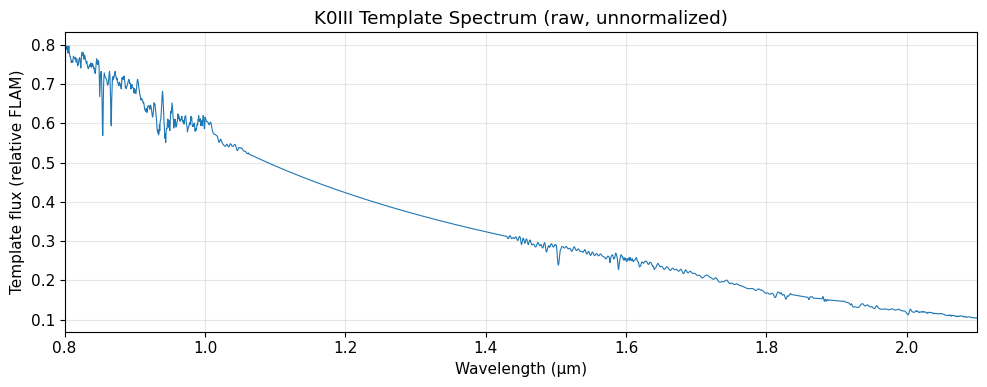

In [3]:
# Load the K0III template spectrum
spectrum_file = project_root / "workbench" / "20260220-grizli-comparison" / "ukk0iii.dat"
raw_data = np.loadtxt(spectrum_file, comments='#')

wl_template_angstrom = raw_data[:, 0]  # Wavelength in Angstroms
flux_template = raw_data[:, 1]          # Flux (ukf_k0iii column)

print(f"Loaded: {spectrum_file.name}")
print(f"  Wavelength range: {wl_template_angstrom[0]:.0f} – {wl_template_angstrom[-1]:.0f} Å")
print(f"  N samples: {len(wl_template_angstrom)}")
print(f"  Flux range (non-zero): {flux_template[flux_template > 0].min():.4f} – {flux_template.max():.4f}")

# Plot the raw template in the grism wavelength range
fig, ax = plt.subplots(figsize=(10, 4))
mask = (wl_template_angstrom >= 8000) & (wl_template_angstrom <= 21000)
ax.plot(wl_template_angstrom[mask] / 1e4, flux_template[mask], lw=0.8)
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Template flux (relative FLAM)')
ax.set_title('K0III Template Spectrum (raw, unnormalized)')
ax.set_xlim(0.8, 2.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Normalize to 1 AB Mag in F158

We use [synphot](https://synphot.readthedocs.io/) to normalize the template spectrum
to a specific AB magnitude in the Roman WFI F158 bandpass:

1. Wrap the raw template as a `synphot.SourceSpectrum` object
2. Load the F158 bandpass from stsynphot's Roman WFI throughput tables
3. Call `normalize()` to scale the spectrum so its synthetic F158 magnitude
   equals our target (1 AB mag)

The result is a properly flux-calibrated spectrum in **FLAM** units
(erg s⁻¹ cm⁻² Å⁻¹).

In [4]:
# Create a synphot SourceSpectrum from the raw template.
# We label the flux as FLAM; since we normalize, the absolute scale is irrelevant.
template_spec = syn.SourceSpectrum(
    syn.Empirical1D,
    points=wl_template_angstrom * u.AA,
    lookup_table=flux_template * syn.units.FLAM,
)

# Load the F158 bandpass
wfi_f158 = stsyn.band('roman, wfi, f158')
print(f"F158 pivot wavelength: {wfi_f158.pivot():.1f}")

# Normalize to target magnitude
norm_spec = template_spec.normalize(MAGNITUDE * u.ABmag, band=wfi_f158)

# Create our wavelength grid and sample the normalized spectrum
wavelengths = np.linspace(LAM_MIN, LAM_MAX, n_wavelength, dtype=np.float64)
wavelengths_angstrom = wavelengths * 1e4  # μm → Å

# Sample FLAM at each wavelength
spectrum_flam = norm_spec(wavelengths_angstrom * u.AA, flux_unit=syn.units.FLAM).value
spectrum_flam = spectrum_flam.astype(np.float32)

print(f"\nNormalized spectrum (mag = {MAGNITUDE} AB in F158):")
print(f"  Peak FLAM: {spectrum_flam.max():.4e} erg/s/cm²/Å")
print(f"  At 1.5 μm:  {np.interp(1.5, wavelengths, spectrum_flam):.4e} erg/s/cm²/Å")

F158 pivot wavelength: 15748.7 Angstrom

Normalized spectrum (mag = 1.0 AB in F158):
  Peak FLAM: 4.8918e-10 erg/s/cm²/Å
  At 1.5 μm:  1.9843e-10 erg/s/cm²/Å


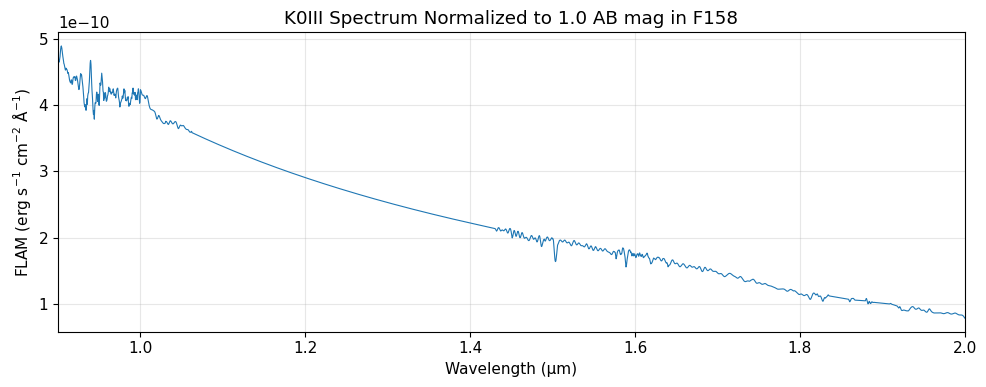

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wavelengths, spectrum_flam, lw=0.8)
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('FLAM (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)')
ax.set_title(f'K0III Spectrum Normalized to {MAGNITUDE} AB mag in F158')
ax.set_xlim(0.9, 2.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Load Grism Sensitivity Curve

The **sensitivity curve** converts flux density (FLAM) into detector counts. It encodes
the combined throughput of the grism, detector quantum efficiency, and telescope
collecting area as a function of wavelength.

The conversion from FLAM to counts per wavelength bin is:

$$\text{counts} = \text{FLAM} \times \text{sensitivity} \times \Delta\lambda$$

where $\Delta\lambda$ is the wavelength bin width in Angstroms.

Loaded sensitivity: SCA1_sens_12052024.fits
  Peak: 1.415e+16 at λ = 1.482 μm


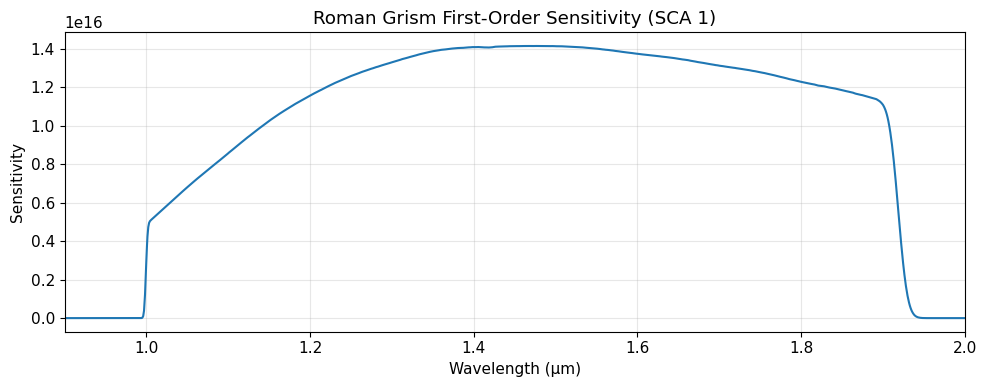

In [6]:
# Load first-order sensitivity for SCA 1
sens_file = project_root / 'data' / 'sensitivities' / 'SCA1_sens_12052024.fits'

with fits.open(sens_file) as hdul:
    sens_data = hdul[1].data
    wl_sens = sens_data['WAVELENGTH'] / 1e4  # Å → μm
    sens_vals = sens_data['SENSITIVITY']

# Interpolate to our wavelength grid
sensitivity = np.interp(wavelengths, wl_sens, sens_vals).astype(np.float32)

print(f"Loaded sensitivity: {sens_file.name}")
print(f"  Peak: {sensitivity.max():.3e} at λ = {wavelengths[np.argmax(sensitivity)]:.3f} μm")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wavelengths, sensitivity, lw=1.5, color='C0')
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Sensitivity')
ax.set_title('Roman Grism First-Order Sensitivity (SCA 1)')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.9, 2.0)
plt.tight_layout()
plt.show()

### Compute the Counts Spectrum

Multiplying FLAM × sensitivity × Δλ gives the number of detected counts in each
wavelength bin. This is the quantity that the star disperser deposits onto the detector
at each wavelength step.

Counts spectrum:
  Δλ = 2.00 Å
  Peak counts/bin: 6.8192e+06
  Total counts (integrated): 2.3187e+10


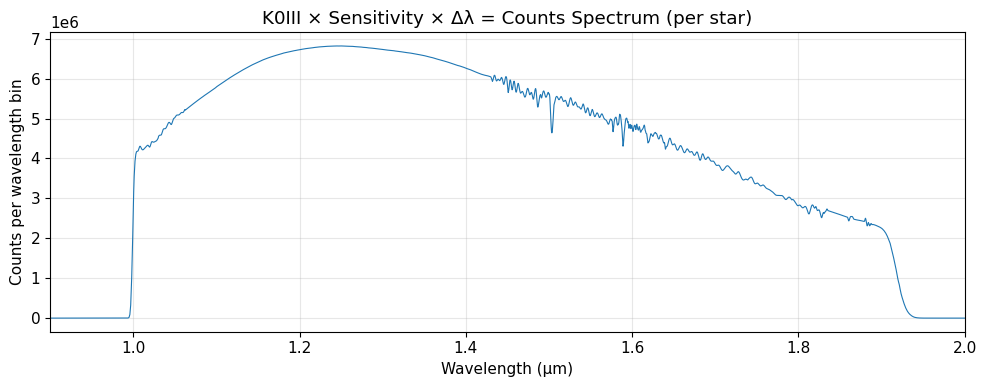

In [7]:
# Convert FLAM to counts: FLAM × sensitivity × Δλ (Å)
dlam_angstroms = (wavelengths[1] - wavelengths[0]) * 1e4  # μm → Å
counts_spectrum = spectrum_flam * sensitivity * dlam_angstroms

# Convert to JAX arrays for the disperser
wavelengths_jax = jnp.array(wavelengths, dtype=jnp.float32)
counts_spectrum_jax = jnp.array(counts_spectrum, dtype=jnp.float32)

print(f"Counts spectrum:")
print(f"  Δλ = {dlam_angstroms:.2f} Å")
print(f"  Peak counts/bin: {counts_spectrum.max():.4e}")
print(f"  Total counts (integrated): {counts_spectrum.sum():.4e}")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wavelengths, counts_spectrum, lw=0.8)
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Counts per wavelength bin')
ax.set_title('K0III × Sensitivity × Δλ = Counts Spectrum (per star)')
ax.set_xlim(0.9, 2.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Load Optical Model and PSF

The star disperser needs two components:

- **Optical model payload:** Polynomial coefficients that map (x, y, λ) positions
  through the grism onto detector coordinates. Created by `make_sca_payload()` for a
  specific SCA and spectral order.

- **PSF payload:** A pre-computed 4×4×56 grid of wavelength- and position-dependent
  point spread functions. Loaded from a cache file generated by STPSF.

These are combined into a single JIT-compiled disperser function via
`make_star_disperser()`, which captures both payloads in a closure.

In [8]:
# Load optical model
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"
model = RomanOpticalModel(config_file=str(config_path))
print(f"Optical model: {config_path.name}")

# Create optical payload for SCA 1, order 1
optical_payload = omj.make_sca_payload(model, sca=SCA, order=ORDER)
print(f"Optical payload: SCA {SCA}, order {ORDER}")

# Load PSF payload from cache
cache_dir = project_root / "data" / "psf_cache"
psf_payload = psf_model.get_or_make_psf_payload(
    detector=DETECTOR,
    order=ORDER,
    cache_dir=str(cache_dir),
    verbose=True,
)
print(f"PSF grid shape: {psf_payload['psf_grid'].shape}")
print(f"PSF grid memory: {psf_payload['psf_grid'].nbytes / 1e6:.1f} MB")

# Create JIT-compiled star disperser
disperser_fn = star_disperser.make_star_disperser(psf_payload, optical_payload)
print(f"\nStar disperser ready (JIT compilation will happen on first call)")

Optical model: Roman_grism_OpticalModel_v0.8.yaml
Optical payload: SCA 1, order 1
Loading PSF payload from cache: /Users/npadmana/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI01_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
Loaded PSF cache: /Users/npadmana/10-Notebook/1-Projects/roman_disperser/data/psf_cache/psf_WFI01_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI01, Order: 1
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB
PSF grid shape: (4, 4, 56, 184, 184)
PSF grid memory: 121.3 MB

Star disperser ready (JIT compilation will happen on first call)


---
## 6. Disperse the Stars

We now disperse each star onto a 4088×4088 detector array. For each star, the
disperser:

1. **Traces the spectrum:** Computes where each wavelength lands on the detector using
   the optical model polynomials
2. **Interpolates the PSF:** Looks up the wavelength- and position-dependent PSF from
   the pre-computed grid
3. **Deposits flux:** Places each PSF (scaled by the counts spectrum) at the dispersed
   position using sub-pixel accumulation
4. **Chunks wavelengths:** Processes wavelengths in chunks via `jax.lax.scan` to keep
   memory usage bounded (~620 MB peak)

Since all 5 stars share the same counts spectrum, we compute it once and reuse it.

**JIT warmup:** The first call to the disperser triggers JAX compilation (~2s).
Subsequent calls reuse the compiled code and run much faster.

In [9]:
# JIT warmup — compile the disperser with the actual array shapes.
# JAX recompiles when input shapes change, so we use the real arrays here.
print("Compiling disperser (JIT warmup)...")
warmup_output = jnp.zeros((4088, 4088), dtype=jnp.float32)

t0 = time.time()
_ = disperser_fn(2000.0, 2000.0, wavelengths_jax, counts_spectrum_jax, warmup_output)
_.block_until_ready()
print(f"Compilation complete in {time.time() - t0:.2f}s")

Compiling disperser (JIT warmup)...
Compilation complete in 1.92s


In [10]:
# Disperse all 5 stars
print(f"Dispersing {N_STARS} stars through order {ORDER}...\n")
output = jnp.zeros((4088, 4088), dtype=jnp.float32)

t0 = time.time()
for i, (x, y) in enumerate(STAR_POSITIONS):
    t_star = time.time()
    output = disperser_fn(x, y, wavelengths_jax, counts_spectrum_jax, output)
    output.block_until_ready()
    print(f"  Star {i+1}/{N_STARS}: ({x:.0f}, {y:.0f}) — {time.time() - t_star:.2f}s")

total_time = time.time() - t0
print(f"\nTotal: {total_time:.2f}s ({total_time/N_STARS:.2f}s per star)")

Dispersing 5 stars through order 1...

  Star 1/5: (2043, 2043) — 0.66s
  Star 2/5: (100, 100) — 0.47s
  Star 3/5: (100, 3900) — 0.54s
  Star 4/5: (3900, 100) — 0.44s
  Star 5/5: (3900, 3900) — 0.56s

Total: 2.67s (0.53s per star)


In [11]:
output_np = np.array(output)

expected_per_star = float(counts_spectrum.sum())
print(f"Output statistics:")
print(f"  Shape:          {output_np.shape}")
print(f"  Total flux:     {output_np.sum():.6e} counts")
print(f"  Peak pixel:     {output_np.max():.6e} counts")
print(f"  Non-zero pixels: {(output_np > 0).sum()} ({100 * (output_np > 0).sum() / output_np.size:.2f}%)")
print(f"")
print(f"  Expected per star:  {expected_per_star:.6e} counts")
print(f"  Expected total (5): {5 * expected_per_star:.6e} counts")
print(f"  Flux ratio (actual/expected): {output_np.sum() / (5 * expected_per_star):.6f}")

Output statistics:
  Shape:          (4088, 4088)
  Total flux:     8.064683e+10 counts
  Peak pixel:     1.991390e+07 counts
  Non-zero pixels: 158149 (0.95%)

  Expected per star:  2.318681e+10 counts
  Expected total (5): 1.159340e+11 counts
  Flux ratio (actual/expected): 0.695627


---
## 7. Visualization

We show the full detector image and zoomed views around each star.

The **asinh stretch** (standard in astronomical imaging, used by SDSS) behaves
linearly near zero and logarithmically for bright values. The `linear_width` parameter
sets the transition point.

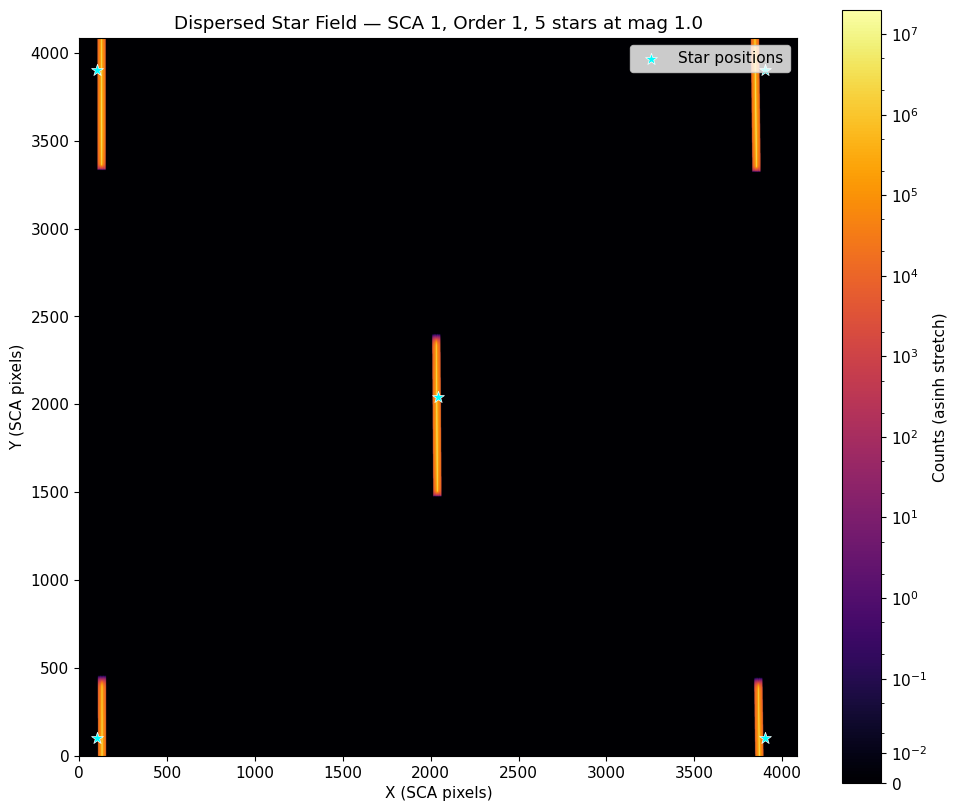

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

norm = AsinhNorm(linear_width=0.01, vmin=0, vmax=output_np.max())
im = ax.imshow(output_np, origin='lower', cmap='inferno', norm=norm)

# Mark star positions
xs = [p[0] for p in STAR_POSITIONS]
ys = [p[1] for p in STAR_POSITIONS]
ax.scatter(xs, ys, s=80, c='cyan', marker='*', edgecolors='white', linewidths=0.5,
           label='Star positions', zorder=5)

ax.set_title(f'Dispersed Star Field \u2014 SCA {SCA}, Order {ORDER}, {N_STARS} stars at mag {MAGNITUDE}')
ax.set_xlabel('X (SCA pixels)')
ax.set_ylabel('Y (SCA pixels)')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='Counts (asinh stretch)', shrink=0.8)
plt.tight_layout()
plt.show()

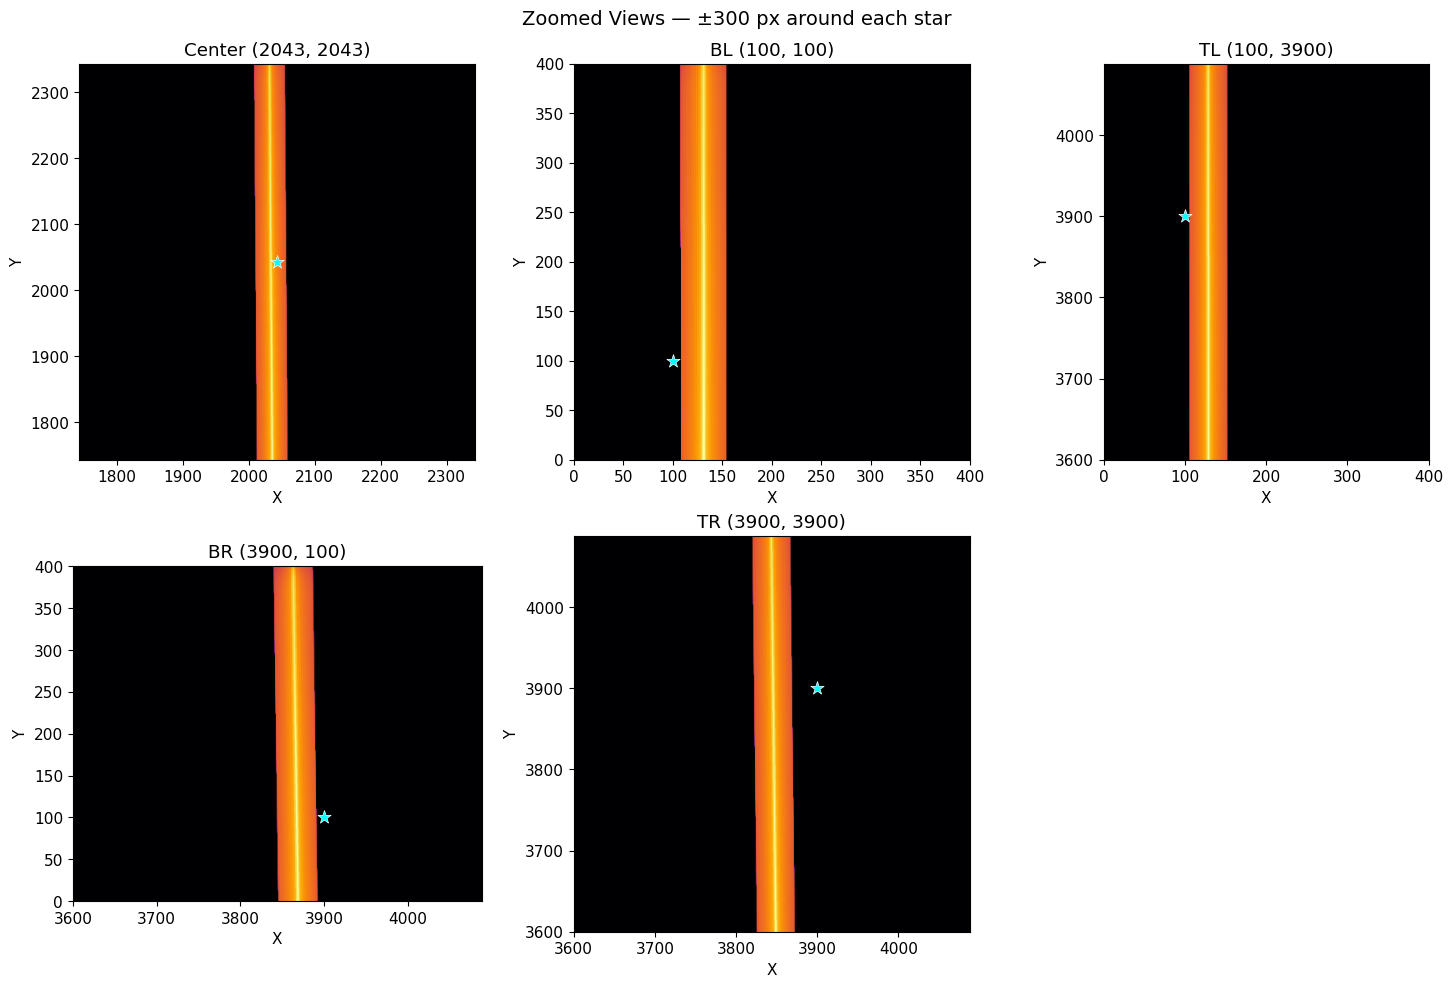

In [14]:
# Zoomed view around each star
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes_flat = axes.ravel()

zoom_half = 300  # pixels around each star

labels = [
    'Center (2043, 2043)',
    'BL (100, 100)',
    'TL (100, 3900)',
    'BR (3900, 100)',
    'TR (3900, 3900)',
]

for i, ((x0, y0), label) in enumerate(zip(STAR_POSITIONS, labels)):
    ax = axes_flat[i]

    x_lo = max(0, int(x0) - zoom_half)
    x_hi = min(4088, int(x0) + zoom_half)
    y_lo = max(0, int(y0) - zoom_half)
    y_hi = min(4088, int(y0) + zoom_half)

    zoomed = output_np[y_lo:y_hi, x_lo:x_hi]

    if zoomed.max() > 0:
        znorm = AsinhNorm(linear_width=0.1, vmin=0, vmax=zoomed.max())
    else:
        znorm = None

    im = ax.imshow(zoomed, origin='lower', cmap='inferno', norm=znorm,
                   extent=[x_lo, x_hi, y_lo, y_hi])
    ax.scatter([x0], [y0], s=100, c='cyan', marker='*',
               edgecolors='white', linewidths=0.5)
    ax.set_title(label)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

# Hide unused subplot
axes_flat[5].set_visible(False)

plt.suptitle(f'Zoomed Views \u2014 \u00b1{zoom_half} px around each star', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Compare with Grizli Model

Load the grizli simulation output (`MODEL` HDU) and compare with our dispersed image.

**Notes:**
- The grizli MODEL is in **electrons/s** (`BUNIT = 'ELECTRONS/S'`).
  Our sensitivity-based conversion also produces a count rate, so the images should be
  directly comparable without scaling.
- Both images are 4088×4088 on SCA 1, first order only.
- The two codes use **different approaches for wavelength-dependent PSFs**, so we do not
  expect pixel-exact agreement. The goal is to check whether the differences are
  physically reasonable.

**Noise floor:** The zodiacal background is ~0.64 e/s/pixel. After background
subtraction, the residual noise is set by shot noise: σ ≈ √(0.64 × t) / t = √0.64 / √t.
We use √0.64 / 100 ≈ 0.008 e/s as our threshold — equivalent to the noise in a
~10,000s exposure, well below typical Roman grism observations (~1500s). This is
conservative enough to remove the faint PSF wing differences while keeping all
astrophysically meaningful signal.

In [41]:
# Load grizli MODEL image
grizli_file = (
    project_root / "workbench" / "20260220-grizli-comparison" / "data"
    / "grism_ra10_dec0_pa60_detSCA01.fits"
)

with fits.open(grizli_file) as hdul:
    grizli_model = hdul['MODEL'].data.astype(np.float32)

# Noise floor: shot noise from zodiacal background (0.64 e/s/pixel)
# after background subtraction, for a ~10,000s equivalent exposure
ZODI_RATE = 0.64  # e/s/pixel
NOISE_FLOOR = np.sqrt(ZODI_RATE) / 100  # ≈ 0.008 e/s/pixel

# Stats
print(f"Loaded: {grizli_file.name}")
print(f"Noise floor: {NOISE_FLOOR:.4f} e/s/pixel (sqrt({ZODI_RATE}) / 100)")
print()
print(f"{'':30s} {'roman_disperser':>16s} {'grizli':>16s}")
print("-" * 66)
print(f"{'Total flux (e/s)':30s} {output_np.sum():16.4e} {grizli_model.sum():16.4e}")
print(f"{'Peak pixel (e/s)':30s} {output_np.max():16.4e} {grizli_model.max():16.4e}")
print(f"{'Non-zero pixels':30s} {(output_np > 0).sum():16d} {(grizli_model > 0).sum():16d}")
print(f"{'Pixels > noise floor':30s} {(output_np > NOISE_FLOOR).sum():16d} {(grizli_model > NOISE_FLOOR).sum():16d}")
print()

# Flux above noise floor
ours_above = output_np[output_np > NOISE_FLOOR].sum()
theirs_above = grizli_model[grizli_model > NOISE_FLOOR].sum()
print(f"{'Flux above noise floor':30s} {ours_above:16.4e} {theirs_above:16.4e}")
print(f"{'Flux ratio (ours/grizli)':30s} {output_np.sum() / grizli_model.sum():16.6f}")
print(f"{'  above noise floor only':30s} {ours_above / theirs_above:16.6f}")

Loaded: grism_ra10_dec0_pa60_detSCA01.fits
Noise floor: 0.0080 e/s/pixel (sqrt(0.64) / 100)

                                roman_disperser           grizli
------------------------------------------------------------------
Total flux (e/s)                     8.0647e+10       8.5878e+10
Peak pixel (e/s)                     1.9914e+07       1.8022e+07
Non-zero pixels                          158149          1481518
Pixels > noise floor                     157652          1465575

Flux above noise floor               8.0647e+10       8.5878e+10
Flux ratio (ours/grizli)               0.939083
  above noise floor only               0.939083


### Side-by-side: Full Detector

Both images shown with `vmin = NOISE_FLOOR` so that pixels below the detection
threshold appear black. This focuses the comparison on the signal that matters.

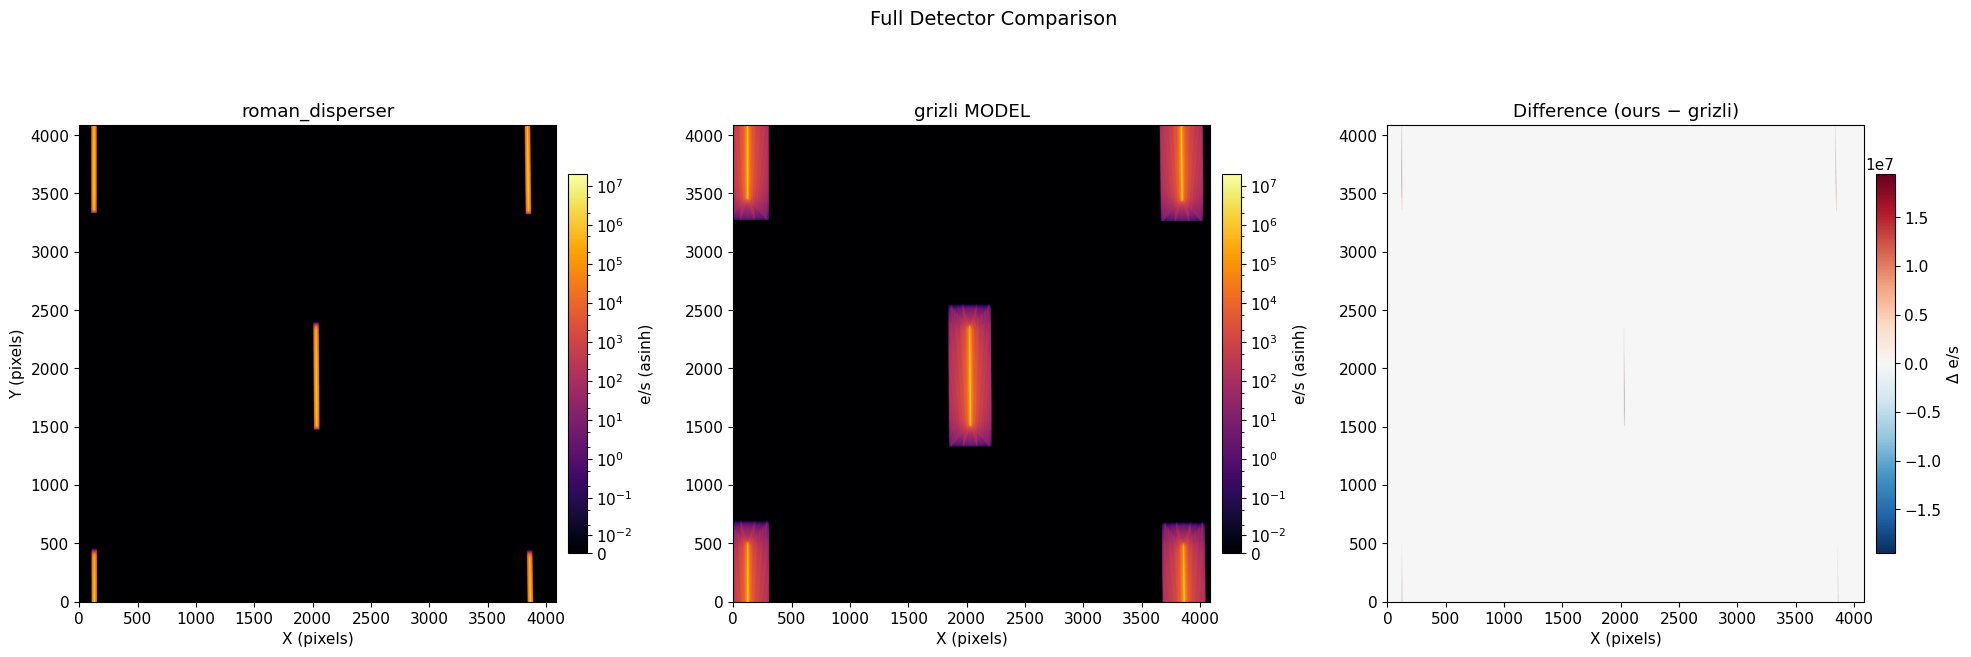

In [42]:
# Side-by-side full detector views
# Use noise floor as vmin to hide sub-threshold PSF wings
vmax = max(output_np.max(), grizli_model.max())
norm = AsinhNorm(linear_width=NOISE_FLOOR, vmin=0, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(20, 7),
                         gridspec_kw={'width_ratios': [1, 1, 1]})

im1 = axes[0].imshow(output_np, origin='lower', cmap='inferno', norm=norm)
axes[0].set_title('roman_disperser')
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')

im2 = axes[1].imshow(grizli_model, origin='lower', cmap='inferno', norm=norm)
axes[1].set_title('grizli MODEL')
axes[1].set_xlabel('X (pixels)')

# Difference — clip to noise floor scale
diff_full = output_np - grizli_model
# Show difference only where either image is above noise floor
significant = (output_np > NOISE_FLOOR) | (grizli_model > NOISE_FLOOR)
diff_masked = np.where(significant, diff_full, 0)
dmax = np.abs(diff_masked).max()
im3 = axes[2].imshow(diff_masked, origin='lower', cmap='RdBu_r', vmin=-dmax, vmax=dmax)
axes[2].set_title('Difference (ours \u2212 grizli)')
axes[2].set_xlabel('X (pixels)')

fig.colorbar(im1, ax=axes[0], label='e/s (asinh)', shrink=0.6, pad=0.02)
fig.colorbar(im2, ax=axes[1], label='e/s (asinh)', shrink=0.6, pad=0.02)
fig.colorbar(im3, ax=axes[2], label='\u0394 e/s', shrink=0.6, pad=0.02)

plt.suptitle('Full Detector Comparison', fontsize=14)
plt.tight_layout()
plt.show()

### Zoomed Comparison: Each Star

Each row shows one star: roman_disperser (left), grizli (center), and the
**absolute difference** `ours - grizli` (right). The difference image directly reveals
trace position offsets and PSF shape discrepancies.

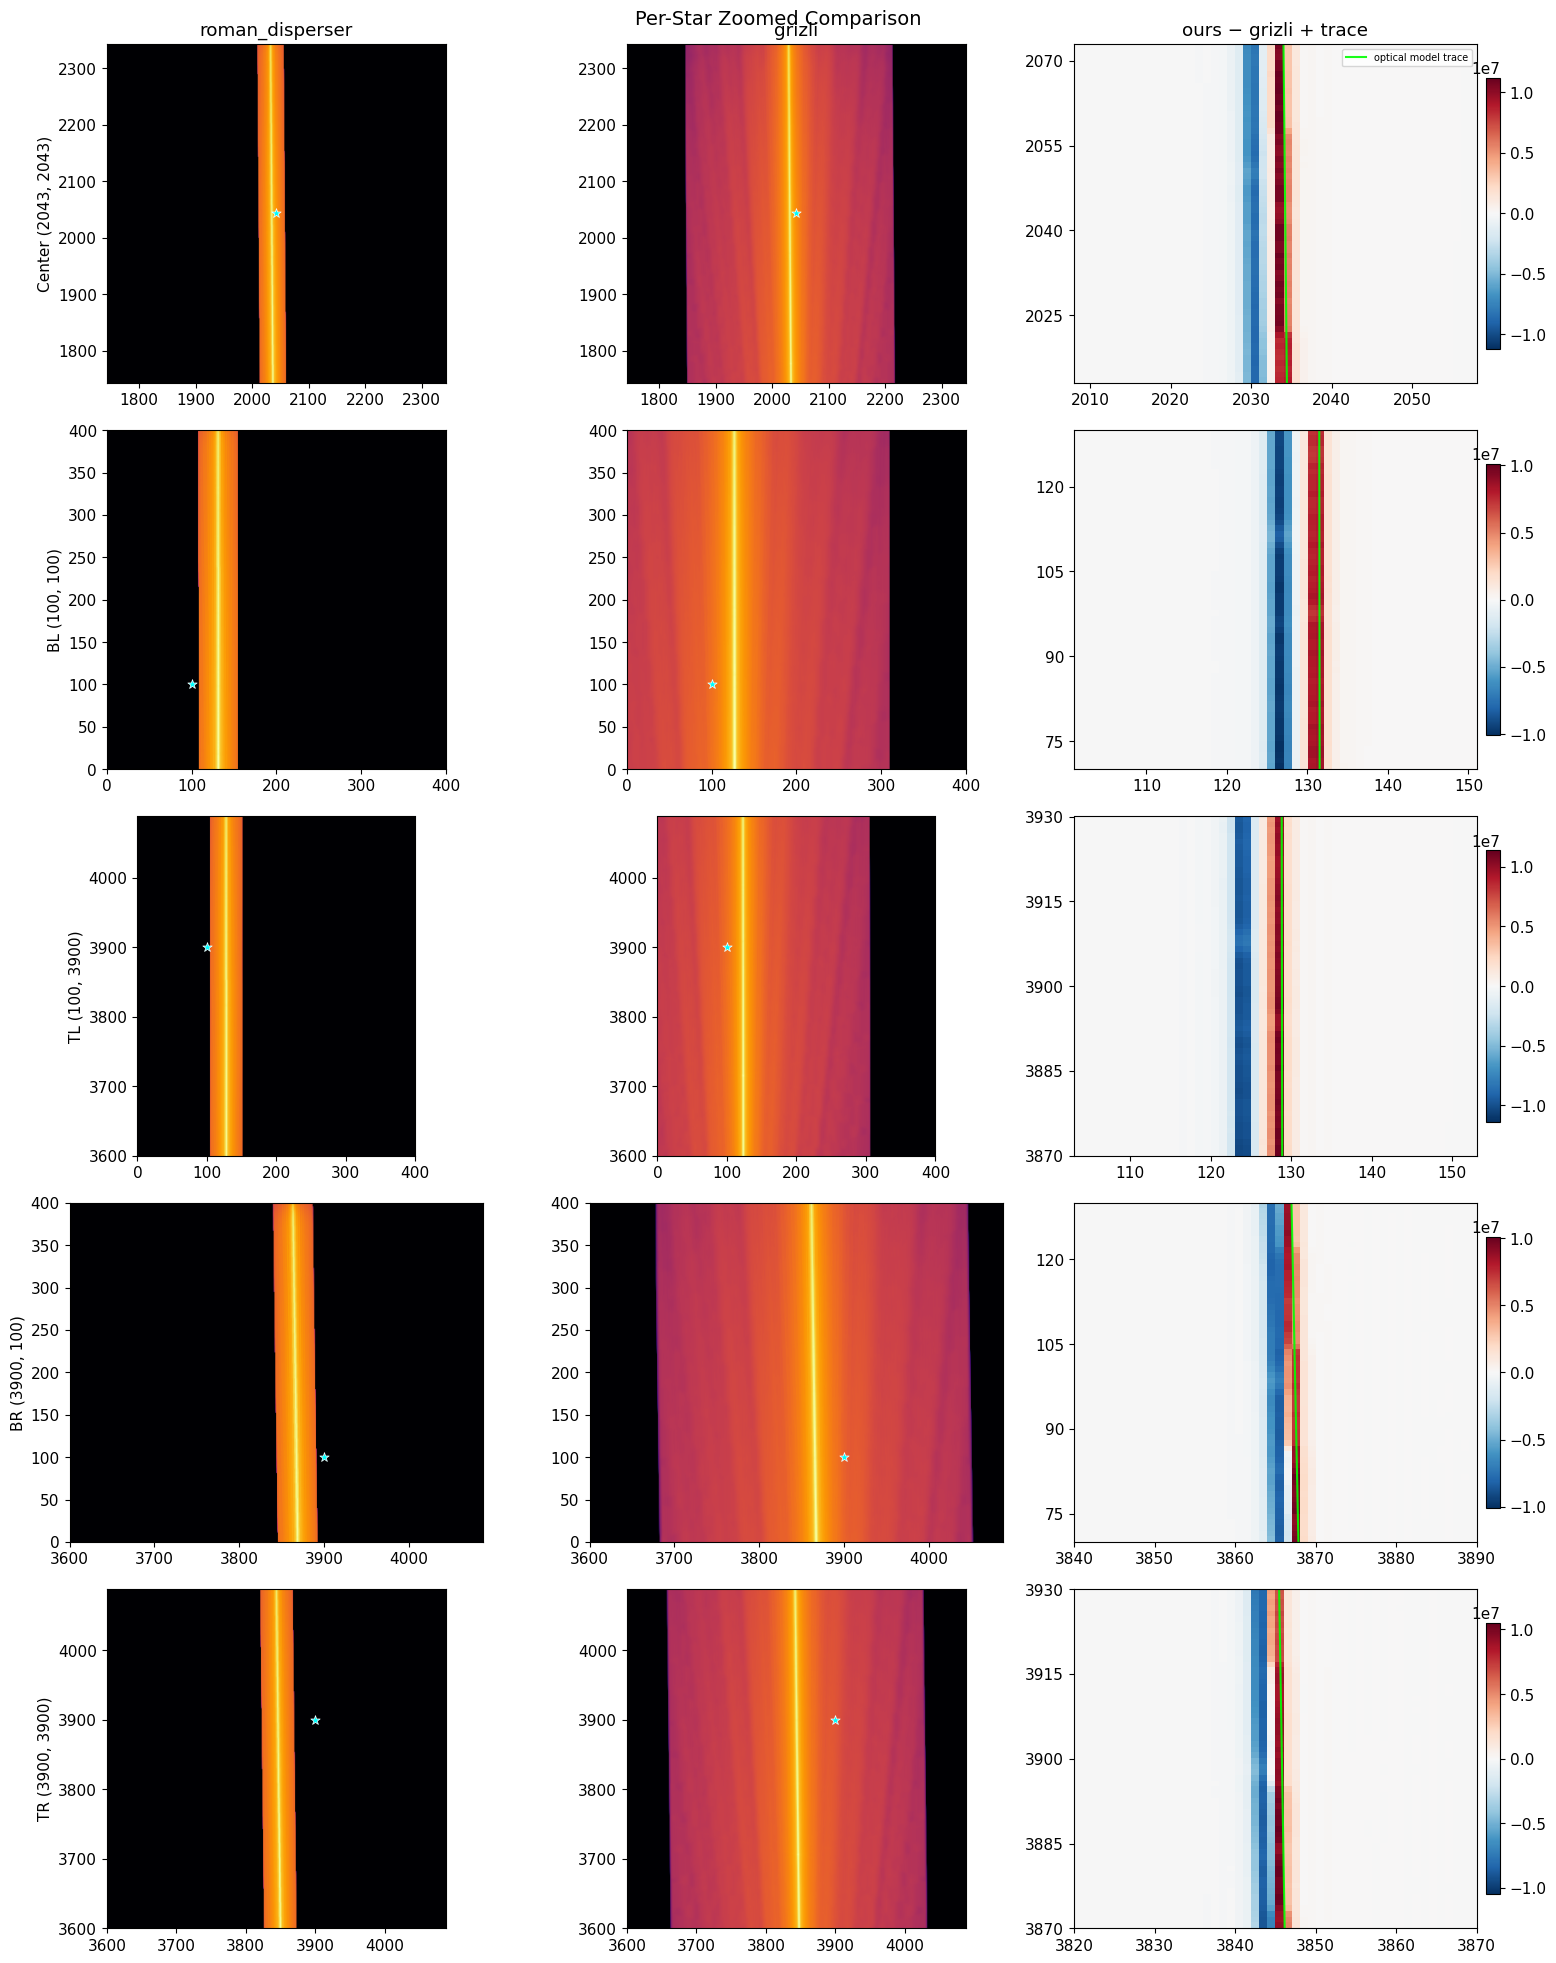

In [63]:
# Zoomed three-panel comparison: ours | grizli | difference (trace close-up)
# Overplot the optical model trace (class-based, non-JAX) on the difference panel
labels = [
    'Center (2043, 2043)',
    'BL (100, 100)',
    'TL (100, 3900)',
    'BR (3900, 100)',
    'TR (3900, 3900)',
]

diff_y_half = 30  # pixels above/below star in cross-dispersion
diff_x_half = 25  # pixels left/right of peak in difference panel
search_x_half = 500  # search for peak within this many pixels of star x
zoom_half = 300   # for the overview panels

# Use a fine wavelength grid for smooth trace lines
wl_grid_orig = model.wl_grid.copy()
model.wl_grid = np.linspace(model.wl_min, model.wl_max, 500)

fig, axes = plt.subplots(N_STARS, 3, figsize=(16, 4 * N_STARS))

for i, ((x0, y0), label) in enumerate(zip(STAR_POSITIONS, labels)):
    # Overview panels: wide view
    x_lo = max(0, int(x0) - zoom_half)
    x_hi = min(4088, int(x0) + zoom_half)
    y_lo = max(0, int(y0) - zoom_half)
    y_hi = min(4088, int(y0) + zoom_half)

    ours = output_np[y_lo:y_hi, x_lo:x_hi]
    theirs = grizli_model[y_lo:y_hi, x_lo:x_hi]
    extent = [x_lo, x_hi, y_lo, y_hi]

    vmax_i = max(ours.max(), theirs.max(), 1.0)
    znorm = AsinhNorm(linear_width=NOISE_FLOOR, vmin=0, vmax=vmax_i)

    axes[i, 0].imshow(ours, origin='lower', cmap='inferno', norm=znorm, extent=extent)
    axes[i, 0].set_ylabel(label)
    if i == 0:
        axes[i, 0].set_title('roman_disperser')

    axes[i, 1].imshow(theirs, origin='lower', cmap='inferno', norm=znorm, extent=extent)
    if i == 0:
        axes[i, 1].set_title('grizli')

    # Compute optical model trace (class-based, non-JAX) with fine wavelength grid
    xfpa, yfpa = model.coords.convert_sca_to_fpa(x0, y0, sca=SCA)
    trace = model._get_beam_trace(xfpa, yfpa, sca=SCA, width=1, order=ORDER)
    trace_x = trace['trace_sca_x'].ravel()
    trace_y = trace['trace_sca_y'].ravel()

    # Auto-detect x range: find peak difference column near this star's x position
    dy_lo = max(0, int(y0) - diff_y_half)
    dy_hi = min(4088, int(y0) + diff_y_half)
    strip = np.abs(output_np[dy_lo:dy_hi, :] - grizli_model[dy_lo:dy_hi, :])
    col_sum = strip.sum(axis=0)
    # Restrict search to within search_x_half of star position
    sx_lo = max(0, int(x0) - search_x_half)
    sx_hi = min(4088, int(x0) + search_x_half)
    peak_x = sx_lo + int(np.argmax(col_sum[sx_lo:sx_hi]))
    dx_lo = max(0, peak_x - diff_x_half)
    dx_hi = min(4088, peak_x + diff_x_half)

    # Difference panel — zoomed x and y, aspect='auto' to fill the subplot
    diff = output_np[dy_lo:dy_hi, dx_lo:dx_hi] - grizli_model[dy_lo:dy_hi, dx_lo:dx_hi]
    diff_extent = [dx_lo, dx_hi, dy_lo, dy_hi]
    dmax = np.abs(diff).max()
    if dmax == 0:
        dmax = 1.0
    im = axes[i, 2].imshow(diff, origin='lower', cmap='RdBu_r',
                            vmin=-dmax, vmax=dmax, extent=diff_extent,
                            aspect='auto')

    # Overplot optical model trace on difference panel
    axes[i, 2].plot(trace_x, trace_y, '-', color='lime', lw=1.5, alpha=0.9,
                    label='optical model trace')

    # Lock axis limits to the difference image extent
    axes[i, 2].set_xlim(dx_lo, dx_hi)
    axes[i, 2].set_ylim(dy_lo, dy_hi)

    if i == 0:
        axes[i, 2].set_title('ours \u2212 grizli + trace')
        axes[i, 2].legend(fontsize=7, loc='upper right')

    # Integer tick labels to avoid crowding
    axes[i, 2].xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))
    axes[i, 2].yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))
    fig.colorbar(im, ax=axes[i, 2], shrink=0.8, pad=0.02)

    for j in range(2):
        axes[i, j].scatter([x0], [y0], s=50, c='cyan', marker='*',
                           edgecolors='white', linewidths=0.5)

# Restore original wavelength grid
model.wl_grid = wl_grid_orig

plt.suptitle('Per-Star Zoomed Comparison', fontsize=14)
plt.tight_layout()
plt.show()

### Rescaling to a Realistic Magnitude

The mag-1 star is ~400,000× brighter than a typical bright survey star (mag 15).
At that extreme flux, even sub-percent PSF differences produce visually dramatic
residuals that are physically irrelevant.

Since the dispersion is entirely linear (flux scales as 10^(-0.4 × mag)), we can
rescale both images to mag 15 without re-running the simulation. This shows what the
comparison looks like at a realistic signal level, where the noise floor becomes the
natural cutoff for the faint PSF wings.

In [44]:
# Rescale both images from mag 1 to mag 15
MAG_RESCALE = 15.0
scale_factor = 10 ** (-0.4 * (MAG_RESCALE - MAGNITUDE))

ours_scaled = output_np * scale_factor
grizli_scaled = grizli_model * scale_factor

print(f"Rescaling from mag {MAGNITUDE} to mag {MAG_RESCALE}")
print(f"  Scale factor: {scale_factor:.4e}")
print(f"  Peak pixel:  ours = {ours_scaled.max():.2f},  grizli = {grizli_scaled.max():.2f} e/s")
print(f"  Noise floor: {NOISE_FLOOR:.2f} e/s")
print(f"  Pixels > noise floor:  ours = {(ours_scaled > NOISE_FLOOR).sum()},  "
      f"grizli = {(grizli_scaled > NOISE_FLOOR).sum()}")

Rescaling from mag 1.0 to mag 15.0
  Scale factor: 2.5119e-06
  Peak pixel:  ours = 50.02,  grizli = 45.27 e/s
  Noise floor: 0.01 e/s
  Pixels > noise floor:  ours = 146929,  grizli = 298434


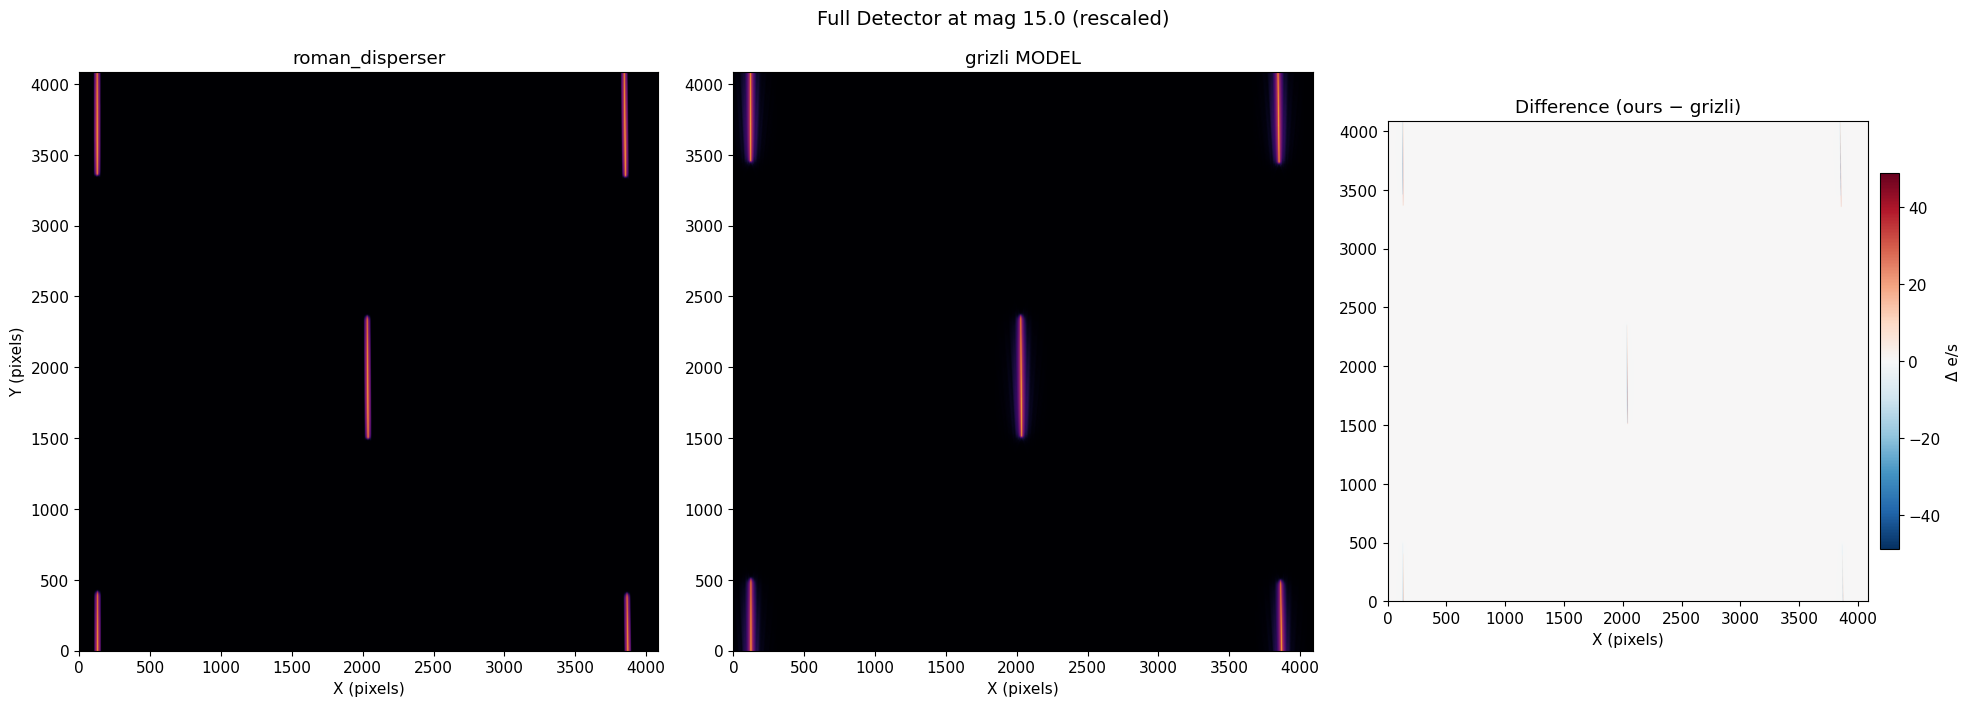

In [45]:
# Side-by-side at mag 15
vmax_s = max(ours_scaled.max(), grizli_scaled.max())
norm_s = AsinhNorm(linear_width=NOISE_FLOOR, vmin=0, vmax=vmax_s)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(ours_scaled, origin='lower', cmap='inferno', norm=norm_s)
axes[0].set_title('roman_disperser')
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')

axes[1].imshow(grizli_scaled, origin='lower', cmap='inferno', norm=norm_s)
axes[1].set_title('grizli MODEL')
axes[1].set_xlabel('X (pixels)')

# Difference, masked to significant pixels
diff_s = ours_scaled - grizli_scaled
sig_s = (ours_scaled > NOISE_FLOOR) | (grizli_scaled > NOISE_FLOOR)
diff_s_masked = np.where(sig_s, diff_s, 0)
dmax_s = np.abs(diff_s_masked).max()
im3 = axes[2].imshow(diff_s_masked, origin='lower', cmap='RdBu_r', vmin=-dmax_s, vmax=dmax_s)
axes[2].set_title('Difference (ours \u2212 grizli)')
axes[2].set_xlabel('X (pixels)')
fig.colorbar(im3, ax=axes[2], label='\u0394 e/s', shrink=0.6, pad=0.02)

plt.suptitle(f'Full Detector at mag {MAG_RESCALE} (rescaled)', fontsize=14)
plt.tight_layout()
plt.show()

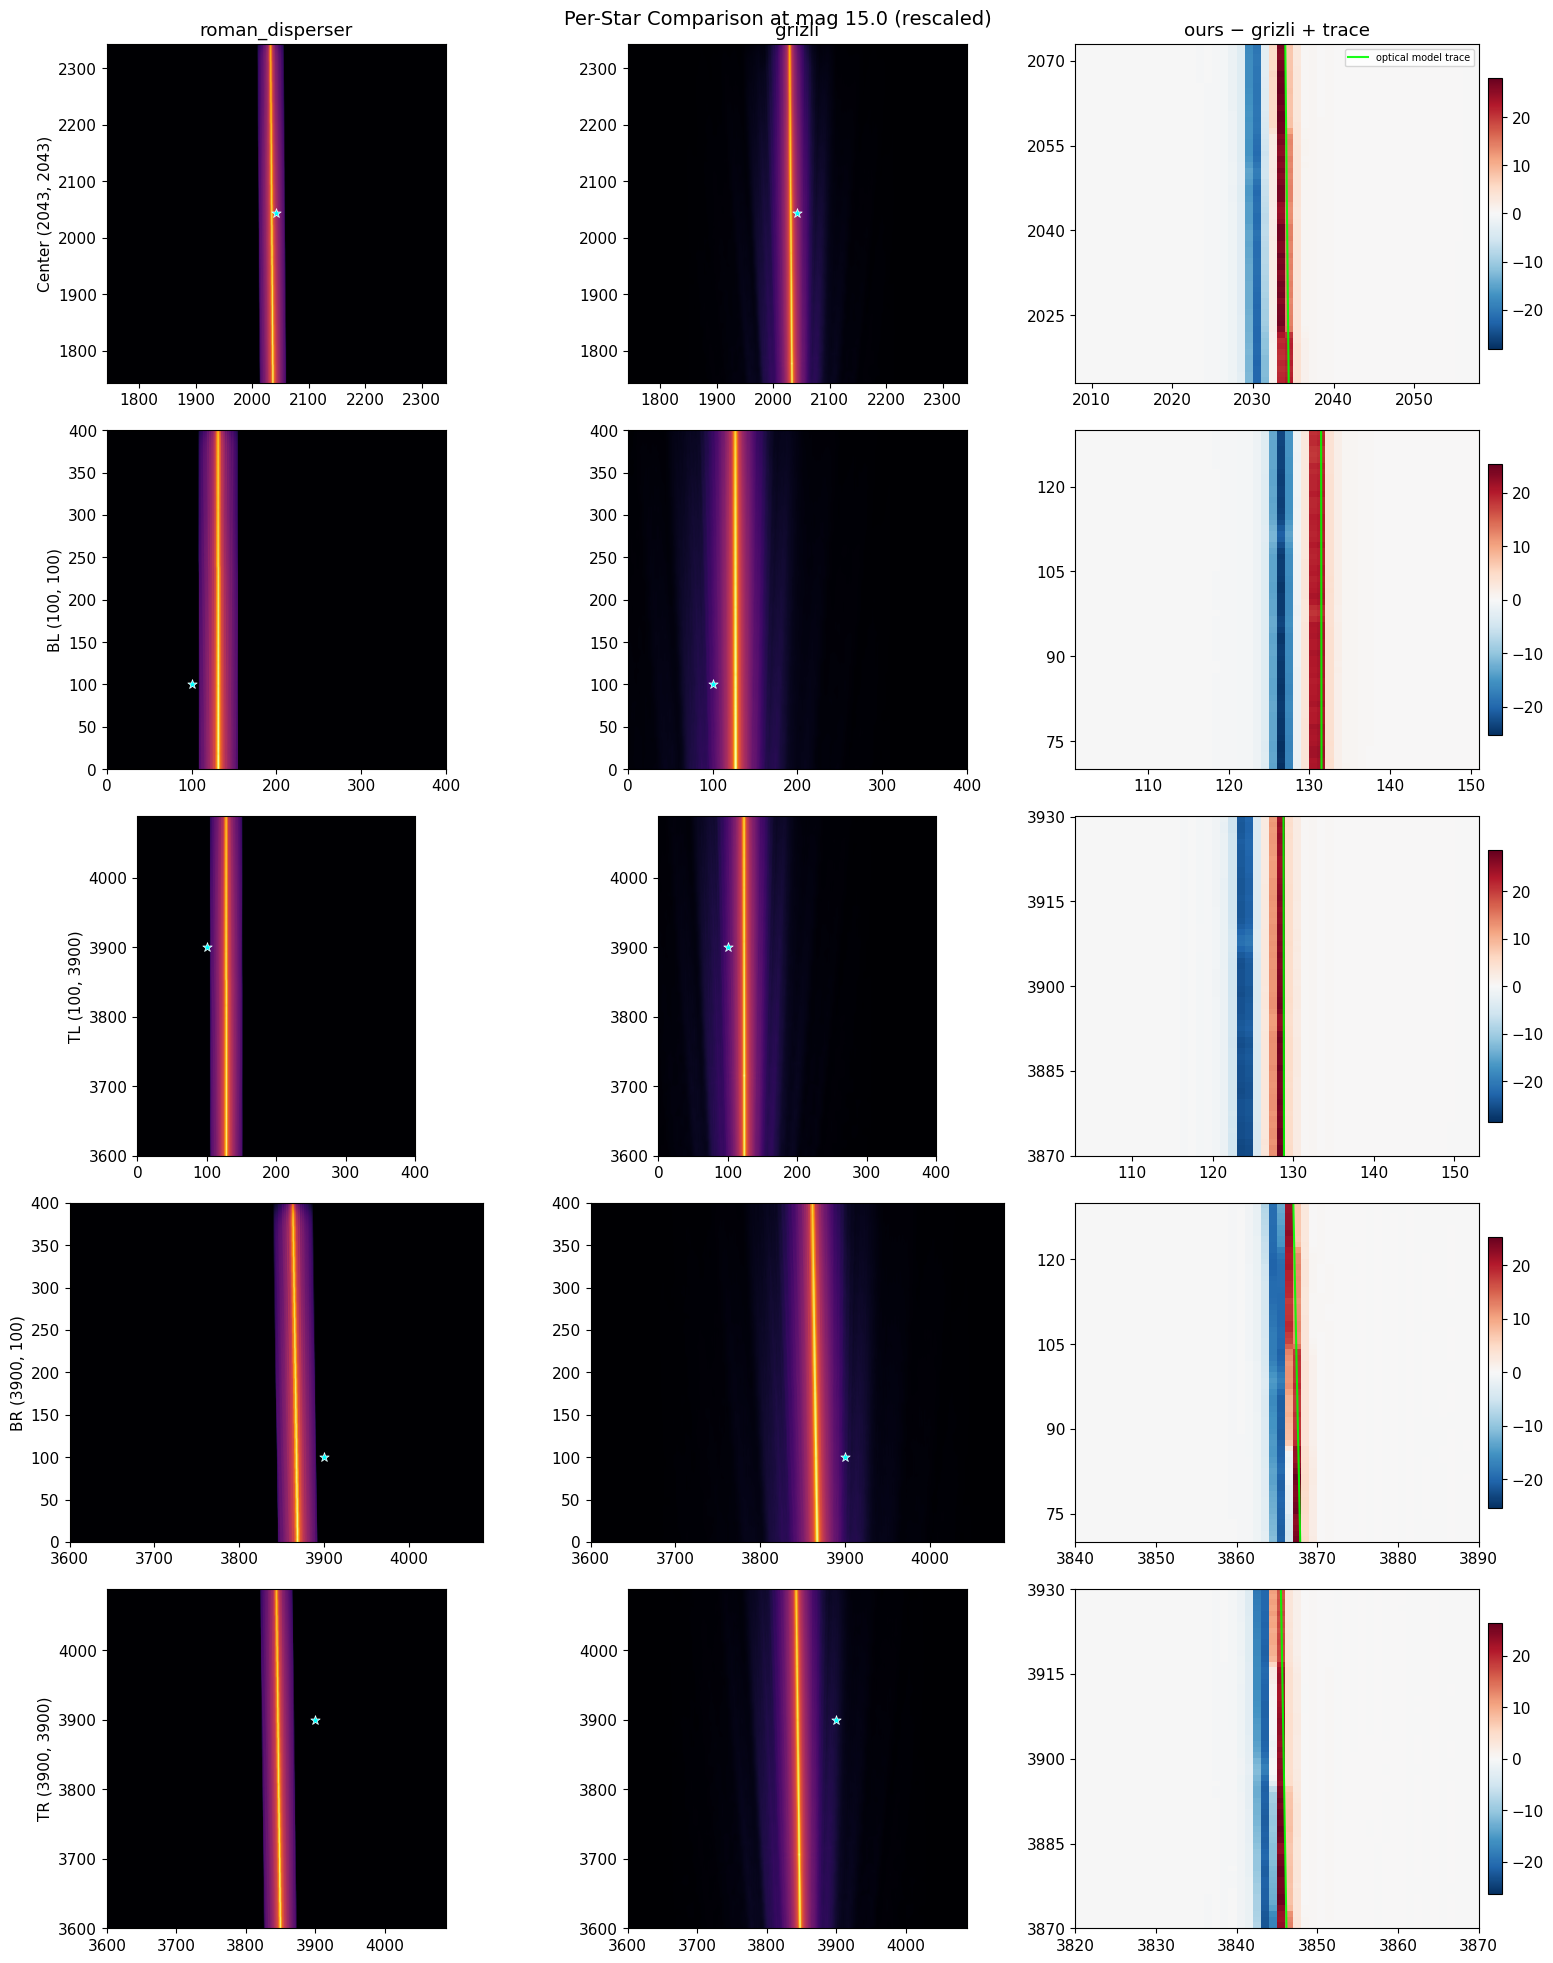

In [64]:
# Zoomed per-star at mag 15: ours | grizli | difference (trace close-up)
# Overplot the optical model trace (class-based, non-JAX) on the difference panel
labels = [
    'Center (2043, 2043)',
    'BL (100, 100)',
    'TL (100, 3900)',
    'BR (3900, 100)',
    'TR (3900, 3900)',
]

diff_y_half = 30
diff_x_half = 25
search_x_half = 500
zoom_half = 300

# Use a fine wavelength grid for smooth trace lines
wl_grid_orig = model.wl_grid.copy()
model.wl_grid = np.linspace(model.wl_min, model.wl_max, 500)

fig, axes = plt.subplots(N_STARS, 3, figsize=(16, 4 * N_STARS))

for i, ((x0, y0), label) in enumerate(zip(STAR_POSITIONS, labels)):
    x_lo = max(0, int(x0) - zoom_half)
    x_hi = min(4088, int(x0) + zoom_half)
    y_lo = max(0, int(y0) - zoom_half)
    y_hi = min(4088, int(y0) + zoom_half)

    ours = ours_scaled[y_lo:y_hi, x_lo:x_hi]
    theirs = grizli_scaled[y_lo:y_hi, x_lo:x_hi]
    extent = [x_lo, x_hi, y_lo, y_hi]

    vmax_i = max(ours.max(), theirs.max(), NOISE_FLOOR * 10)
    znorm = AsinhNorm(linear_width=NOISE_FLOOR, vmin=0, vmax=vmax_i)

    axes[i, 0].imshow(ours, origin='lower', cmap='inferno', norm=znorm, extent=extent)
    axes[i, 0].set_ylabel(label)
    if i == 0:
        axes[i, 0].set_title('roman_disperser')

    axes[i, 1].imshow(theirs, origin='lower', cmap='inferno', norm=znorm, extent=extent)
    if i == 0:
        axes[i, 1].set_title('grizli')

    # Compute optical model trace (class-based, non-JAX) with fine wavelength grid
    xfpa, yfpa = model.coords.convert_sca_to_fpa(x0, y0, sca=SCA)
    trace = model._get_beam_trace(xfpa, yfpa, sca=SCA, width=1, order=ORDER)
    trace_x = trace['trace_sca_x'].ravel()
    trace_y = trace['trace_sca_y'].ravel()

    # Auto-detect x range: find peak difference column near this star's x position
    dy_lo = max(0, int(y0) - diff_y_half)
    dy_hi = min(4088, int(y0) + diff_y_half)
    strip = np.abs(ours_scaled[dy_lo:dy_hi, :] - grizli_scaled[dy_lo:dy_hi, :])
    col_sum = strip.sum(axis=0)
    # Restrict search to within search_x_half of star position
    sx_lo = max(0, int(x0) - search_x_half)
    sx_hi = min(4088, int(x0) + search_x_half)
    peak_x = sx_lo + int(np.argmax(col_sum[sx_lo:sx_hi]))
    dx_lo = max(0, peak_x - diff_x_half)
    dx_hi = min(4088, peak_x + diff_x_half)

    # Difference panel — zoomed x and y, aspect='auto'
    diff = ours_scaled[dy_lo:dy_hi, dx_lo:dx_hi] - grizli_scaled[dy_lo:dy_hi, dx_lo:dx_hi]
    diff_extent = [dx_lo, dx_hi, dy_lo, dy_hi]
    dmax = np.abs(diff).max()
    if dmax == 0:
        dmax = 1.0
    im = axes[i, 2].imshow(diff, origin='lower', cmap='RdBu_r',
                            vmin=-dmax, vmax=dmax, extent=diff_extent,
                            aspect='auto')

    # Overplot optical model trace on difference panel
    axes[i, 2].plot(trace_x, trace_y, '-', color='lime', lw=1.5, alpha=0.9,
                    label='optical model trace')

    # Lock axis limits to the difference image extent
    axes[i, 2].set_xlim(dx_lo, dx_hi)
    axes[i, 2].set_ylim(dy_lo, dy_hi)

    if i == 0:
        axes[i, 2].set_title('ours \u2212 grizli + trace')
        axes[i, 2].legend(fontsize=7, loc='upper right')

    axes[i, 2].xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))
    axes[i, 2].yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))
    fig.colorbar(im, ax=axes[i, 2], shrink=0.8, pad=0.02)

    for j in range(2):
        axes[i, j].scatter([x0], [y0], s=50, c='cyan', marker='*',
                           edgecolors='white', linewidths=0.5)

# Restore original wavelength grid
model.wl_grid = wl_grid_orig

plt.suptitle(f'Per-Star Comparison at mag {MAG_RESCALE} (rescaled)',
             fontsize=14)
plt.tight_layout()
plt.show()

### Cross-Sections Through the Center Star Trace

1D profiles along and across the dispersed trace of the center star. Dispersion on
SCA 1 is primarily along **y**, so:
- **Profile Along Trace** (left): mean over x = 1800–2300, profile along y — spectral profile
- **Profile Across Trace** (right): mean over y = 1800–2300, profile along x — PSF spatial width

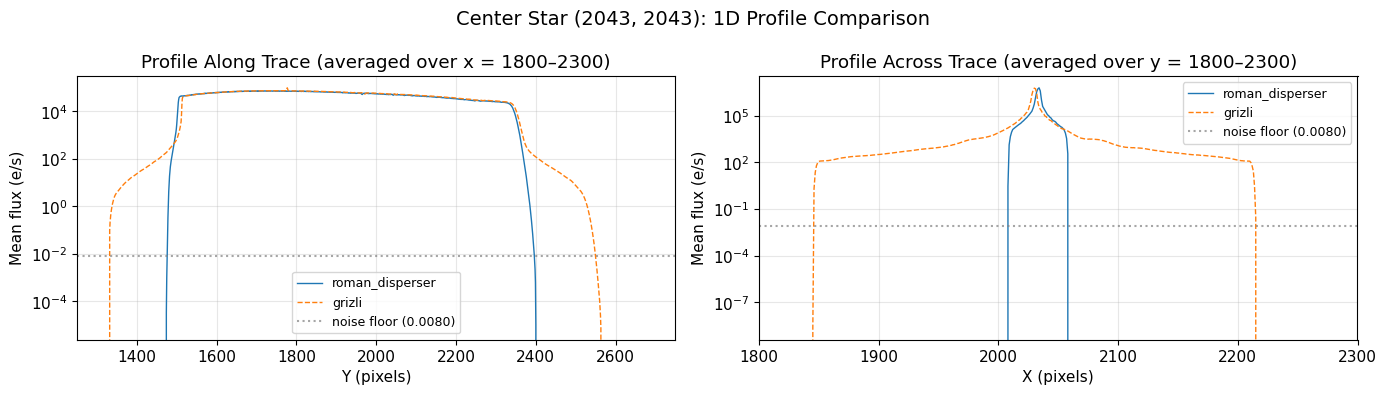

In [88]:
# Cross-sections through the center star (2043, 2043)
# Dispersion is largely along y on SCA 1, so:
#   "profile along trace" = average over x range, profile along y (spectral)
#   "profile across trace" = average over y range, profile along x (spatial PSF)

x_star, y_star = 2043, 2043
x_lo_strip, x_hi_strip = 1800, 2300  # wide x range to capture all flux

# Profile along trace: average columns in [1800:2300], profile along y
along_ours = output_np[:, x_lo_strip:x_hi_strip].mean(axis=1)
along_grizli = grizli_model[:, x_lo_strip:x_hi_strip].mean(axis=1)

# Profile across trace: average rows in [1800:2300], profile along x
cross_ours = output_np[x_lo_strip:x_hi_strip, :].mean(axis=0)
cross_grizli = grizli_model[x_lo_strip:x_hi_strip, :].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Profile along trace (spectral profile along y)
ax = axes[0]
ax.semilogy(along_ours, label='roman_disperser', lw=1)
ax.semilogy(along_grizli, label='grizli', lw=1, ls='--')
ax.axhline(NOISE_FLOOR, color='gray', ls=':', alpha=0.7, label=f'noise floor ({NOISE_FLOOR:.4f})')
ax.set_xlabel('Y (pixels)')
ax.set_ylabel('Mean flux (e/s)')
ax.set_title(f'Profile Along Trace (averaged over x = {x_lo_strip}\u2013{x_hi_strip})')
ax.set_xlim(1250,2750)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Profile across trace (PSF profile along x)
ax = axes[1]
ax.semilogy(cross_ours, label='roman_disperser', lw=1)
ax.semilogy(cross_grizli, label='grizli', lw=1, ls='--')
ax.axhline(NOISE_FLOOR, color='gray', ls=':', alpha=0.7, label=f'noise floor ({NOISE_FLOOR:.4f})')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Mean flux (e/s)')
ax.set_title(f'Profile Across Trace (averaged over y = {x_lo_strip}\u2013{x_hi_strip})')
ax.set_xlim(x_lo_strip, x_hi_strip)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Center Star (2043, 2043): 1D Profile Comparison', fontsize=14)
plt.tight_layout()
plt.show()

### Cross-Sections: BL and TL Corner Stars

Same 1D profiles for the two left-column stars, which share the same x position (100)
but sit at opposite ends of the detector in y. Their flux ratios differ dramatically
(BL ~ 0.71, TL ~ 1.05), so comparing the profiles may reveal where the discrepancy
arises.

Averaging box: x = 0–500 (avoids the right-column stars at x = 3900).
- **BL (100, 100):** y = 0–1000
- **TL (100, 3900):** y = 3000–4088

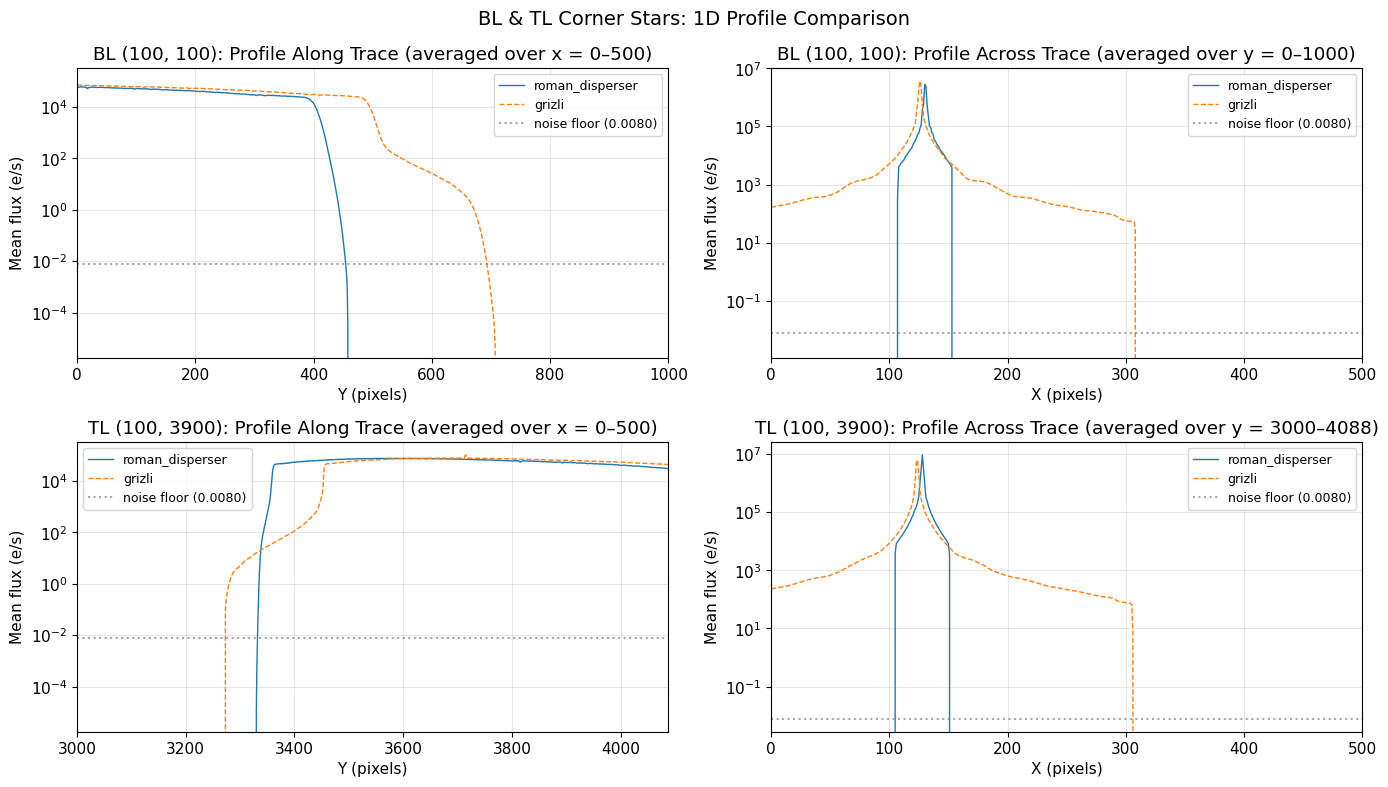

In [89]:
# Cross-sections for BL (100, 100) and TL (100, 3900)
# Both at x=100; averaging over x=0-500 to avoid the right-column stars.
# BL: y=0-1000, TL: y=3000-4088

x_lo_lr, x_hi_lr = 0, 500  # shared x range (left column)

stars_lr = [
    {'label': 'BL (100, 100)', 'x': 100, 'y': 100, 'y_lo': 0, 'y_hi': 1000},
    {'label': 'TL (100, 3900)', 'x': 100, 'y': 3900, 'y_lo': 3000, 'y_hi': 4088},
]

fig, axes = plt.subplots(len(stars_lr), 2, figsize=(14, 4 * len(stars_lr)))

for row, star in enumerate(stars_lr):
    y_lo, y_hi = star['y_lo'], star['y_hi']

    # Profile along trace: average over x=0-500, profile along y
    along_ours = output_np[:, x_lo_lr:x_hi_lr].mean(axis=1)
    along_grizli = grizli_model[:, x_lo_lr:x_hi_lr].mean(axis=1)

    # Profile across trace: average over y range, profile along x
    cross_ours = output_np[y_lo:y_hi, :].mean(axis=0)
    cross_grizli = grizli_model[y_lo:y_hi, :].mean(axis=0)

    # Left: profile along trace (spectral)
    ax = axes[row, 0]
    ax.semilogy(along_ours, label='roman_disperser', lw=1)
    ax.semilogy(along_grizli, label='grizli', lw=1, ls='--')
    ax.axhline(NOISE_FLOOR, color='gray', ls=':', alpha=0.7,
               label=f'noise floor ({NOISE_FLOOR:.4f})')
    ax.set_xlabel('Y (pixels)')
    ax.set_ylabel('Mean flux (e/s)')
    ax.set_title(f'{star["label"]}: Profile Along Trace (averaged over x = {x_lo_lr}\u2013{x_hi_lr})')
    ax.set_xlim(y_lo, y_hi)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Right: profile across trace (spatial PSF)
    ax = axes[row, 1]
    ax.semilogy(cross_ours, label='roman_disperser', lw=1)
    ax.semilogy(cross_grizli, label='grizli', lw=1, ls='--')
    ax.axhline(NOISE_FLOOR, color='gray', ls=':', alpha=0.7,
               label=f'noise floor ({NOISE_FLOOR:.4f})')
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Mean flux (e/s)')
    ax.set_title(f'{star["label"]}: Profile Across Trace (averaged over y = {y_lo}\u2013{y_hi})')
    ax.set_xlim(x_lo_lr, x_hi_lr)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('BL & TL Corner Stars: 1D Profile Comparison', fontsize=14)
plt.tight_layout()
plt.show()

### Per-Star Flux Comparison

Measure the total flux in a box around each star at several magnitudes. The box is
narrow in x (cross-dispersion, ±250 pixels) and long in y (along dispersion, ±800
pixels), clipped at array boundaries. Rescaling is linear from the mag-1 simulation.

In [72]:
# Per-star flux comparison at multiple magnitudes
# Box: narrow in x (cross-dispersion), long in y (along dispersion)
half_x = 250   # cross-dispersion half-width
half_y = 800   # along-dispersion half-width

labels = ['Center', 'BL', 'TL', 'BR', 'TR']
magnitudes = [1.0, 15.0, 17.0, 20.0]

print(f"Box size: ±{half_x} (x, cross-disp) × ±{half_y} (y, along-disp) pixels")
print(f"Noise floor: {NOISE_FLOOR:.4f} e/s/pixel")
print()

for mag in magnitudes:
    scale = 10 ** (-0.4 * (mag - MAGNITUDE))
    nf = NOISE_FLOOR  # noise floor is fixed, independent of star brightness

    print(f"{'=' * 90}")
    print(f"  Magnitude {mag:.0f} AB   (scale factor: {scale:.4e})")
    print(f"{'=' * 90}")
    print(f"  {'Star':<10s} {'ours':>12s} {'grizli':>12s} {'ratio':>8s}  |  "
          f"{'ours>NF':>12s} {'grizli>NF':>12s} {'ratio':>8s}")
    print(f"  {'-' * 84}")

    for (x0, y0), label in zip(STAR_POSITIONS, labels):
        x_lo = max(0, int(x0) - half_x)
        x_hi = min(4088, int(x0) + half_x)
        y_lo = max(0, int(y0) - half_y)
        y_hi = min(4088, int(y0) + half_y)

        ours_box = output_np[y_lo:y_hi, x_lo:x_hi] * scale
        theirs_box = grizli_model[y_lo:y_hi, x_lo:x_hi] * scale

        flux_ours = ours_box.sum()
        flux_grizli = theirs_box.sum()
        ratio_all = flux_ours / flux_grizli if flux_grizli > 0 else np.nan

        flux_ours_nf = ours_box[ours_box > nf].sum()
        flux_grizli_nf = theirs_box[theirs_box > nf].sum()
        ratio_nf = flux_ours_nf / flux_grizli_nf if flux_grizli_nf > 0 else np.nan

        print(f"  {label:<10s} {flux_ours:12.4e} {flux_grizli:12.4e} {ratio_all:8.4f}  |  "
              f"{flux_ours_nf:12.4e} {flux_grizli_nf:12.4e} {ratio_nf:8.4f}")

    print()

Box size: ±250 (x, cross-disp) × ±800 (y, along-disp) pixels
Noise floor: 0.0080 e/s/pixel

  Magnitude 1 AB   (scale factor: 1.0000e+00)
  Star               ours       grizli    ratio  |       ours>NF    grizli>NF    ratio
  ------------------------------------------------------------------------------------
  Center       2.2496e+10   2.3191e+10   0.9700  |    2.2496e+10   2.3191e+10   0.9700
  BL           8.0756e+09   1.1400e+10   0.7084  |    8.0756e+09   1.1400e+10   0.7084
  TL           2.1116e+10   2.0063e+10   1.0525  |    2.1116e+10   2.0063e+10   1.0525
  BR           7.7050e+09   1.0964e+10   0.7028  |    7.7050e+09   1.0964e+10   0.7028
  TR           2.1255e+10   2.0260e+10   1.0491  |    2.1255e+10   2.0260e+10   1.0491

  Magnitude 15 AB   (scale factor: 2.5119e-06)
  Star               ours       grizli    ratio  |       ours>NF    grizli>NF    ratio
  ------------------------------------------------------------------------------------
  Center       5.6507e+04   5.8

---
## Summary

This notebook dispersed 5 test stars through the Roman grism first order using
`roman_disperser` and compared the result against a grizli simulation:

1. **Spectrum:** K0III template from `ukk0iii.dat`, normalized to 1 AB mag (F158)
   using synphot
2. **Sensitivity:** First-order grism sensitivity converts FLAM to counts
3. **Dispersion:** Each star dispersed with wavelength-dependent PSFs (2 Angstrom spacing,
   5501 wavelength samples) onto the 4088x4088 detector
4. **Comparison:** Side-by-side images, fractional difference maps, 1D cross-sections,
   and per-star flux ratios against the grizli `MODEL` HDU

**Comparison approach:** A noise floor of 0.13 e/s (1/5 of the zodiacal background)
was used to focus the comparison on physically meaningful signal. Grizli uses a much
larger PSF footprint, producing ~10x more non-zero pixels, but most of the extra flux
is well below the detection threshold.

**Key diagnostics:**
- **Total flux:** Do the integrated count rates match?
- **Trace position and shape:** Are the dispersed traces in the same location?
- **Fractional differences:** Where (and by how much) do the codes disagree above the noise floor?
- **1D profiles:** Along-trace (spectral) and cross-trace (spatial PSF) comparisons